In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

print("EJERCICIOS PARCIAL")

EJERCICIOS PARCIAL


EJERCICIO 1; Variable Aleatoria 'Diferencia'
Valores X [1 2 3 4 5 6]
Valores Y [1 2 3 4 5 6]
a) Espacio muestral de D= X-Y:
[-5 -4 -3 -2 -1  0  1  2  3  4  5]

b) Tabla de función de masa de probabilidades:
  d | Casos |   P(D=d)
----------------------
 -5 |     1/36 |   0.0278
 -4 |     2/36 |   0.0556
 -3 |     3/36 |   0.0833
 -2 |     4/36 |   0.1111
 -1 |     5/36 |   0.1389
  0 |     6/36 |   0.1667
  1 |     5/36 |   0.1389
  2 |     4/36 |   0.1111
  3 |     3/36 |   0.0833
  4 |     2/36 |   0.0556
  5 |     1/36 |   0.0278

d) Probabilidades:
P(D = 0)         = 0.1667  (6/36)
P(D > 0)         = 0.4167  (15/36)
P(|D| >= 3)      = 0.3333  (12/36)


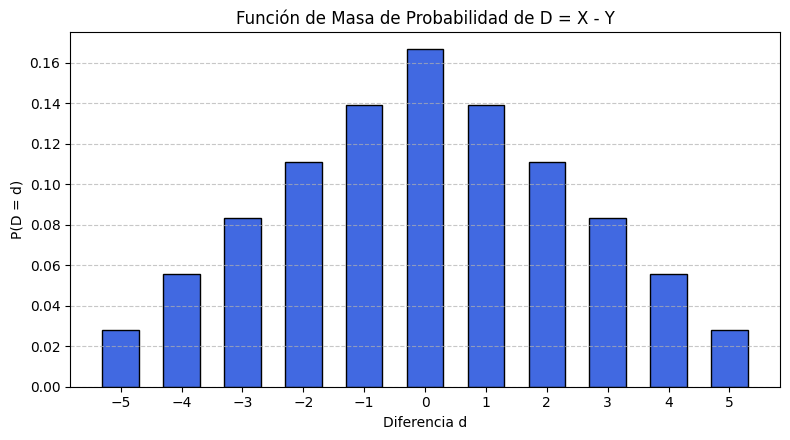

In [ ]:
print("EJERCICIO 1; Variable Aleatoria 'Diferencia'")
# Espacio muestral individual de X y Y (equiprobables con 1/6 cada uno)
Calificaciones = np.array([1, 2, 3, 4, 5, 6])
valoresd = np.arange(1, 7)

# a) Generar todas las combinaciones y el espacio muestral de D = X - Y
# Usamos una cuadrícula (outer subtraction) de 6x6 = 36 pares posibles
diferencias = np.subtract.outer(valoresd, valoresd).flatten()
espacio_muestral_D = np.unique(diferencias)
print("Valores X", Calificaciones)
print("Valores Y", Calificaciones)
print("a) Espacio muestral de D= X-Y:")
print(espacio_muestral_D)

# b) Construir la función de masa de probabilidades P(D = d)
d_vals, conteos = np.unique(diferencias, return_counts=True)
probabilidades = conteos / len(diferencias)

print("\nb) Tabla de función de masa de probabilidades:")
print(f"{'d':>3} | {'Casos':>5} | {'P(D=d)':>8}")
print("-" * 22)
for d, c, p in zip(d_vals, conteos, probabilidades):
    print(f"{d:3d} | {c:5d}/36 | {p:8.4f}")

# d) Cálculos de probabilidad solicitados a partir de la distribución
p_cero = probabilidades[d_vals == 0][0]
p_mayor_cero = probabilidades[d_vals > 0].sum()
p_abs_mayor_igual_3 = probabilidades[np.abs(d_vals) >= 3].sum()

print("\nd) Probabilidades:")
print(f"P(D = 0)         = {p_cero:.4f}  ({int(round(p_cero*36))}/36)")
print(f"P(D > 0)         = {p_mayor_cero:.4f}  ({int(round(p_mayor_cero*36))}/36)")
print(
    f"P(|D| >= 3)      = {p_abs_mayor_igual_3:.4f}  ({int(round(p_abs_mayor_igual_3*36))}/36)"
)

# c) Gráfica de barras de la función de masa de probabilidades
plt.figure(figsize=(8, 4.5))
plt.bar(
    d_vals, probabilidades, width=0.6, color="royalblue", edgecolor="black"
)
plt.title("Función de Masa de Probabilidad de D = X - Y")
plt.xlabel("Diferencia d")
plt.ylabel("P(D = d)")
plt.xticks(d_vals)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

EJERCICIO 3: MCO a partir de datos
 i    xᵢ    yᵢ   xᵢ-x̄    yᵢ-ȳ  producto  (xᵢ-x̄)²
 1     1     3    -2.0    -1.0      2.00      4.00
 2     2     4    -1.0     0.0     -0.00      1.00
 3     3     2     0.0    -2.0     -0.00      0.00
 4     4     5     1.0     1.0      1.00      1.00
 5     5     6     2.0     2.0      4.00      4.00
 Σ                                  7.00     10.00

n = 5      x̄ = 3      ȳ = 4
Sxx = 10    Syy = 10    Sxy = 7
β̂1 = 0.700000     β̂0 = 1.900000
SCRmin = 5.100000   SSE = 4.900000   SST = 10.000000
R² = 0.490000    ρ̂xy = 0.700000
[ecuaciones normales]  Σûᵢ = -1.33e-15    Σxᵢûᵢ = -3.55e-15
Funcion = 1.900000 +0.700000 x
SSE = 4.900000    SSR = 5.100000    SST = 10.000000
SST = 4.900000 + 5.100000= 10.000000 (comprobación SSE+SSR)


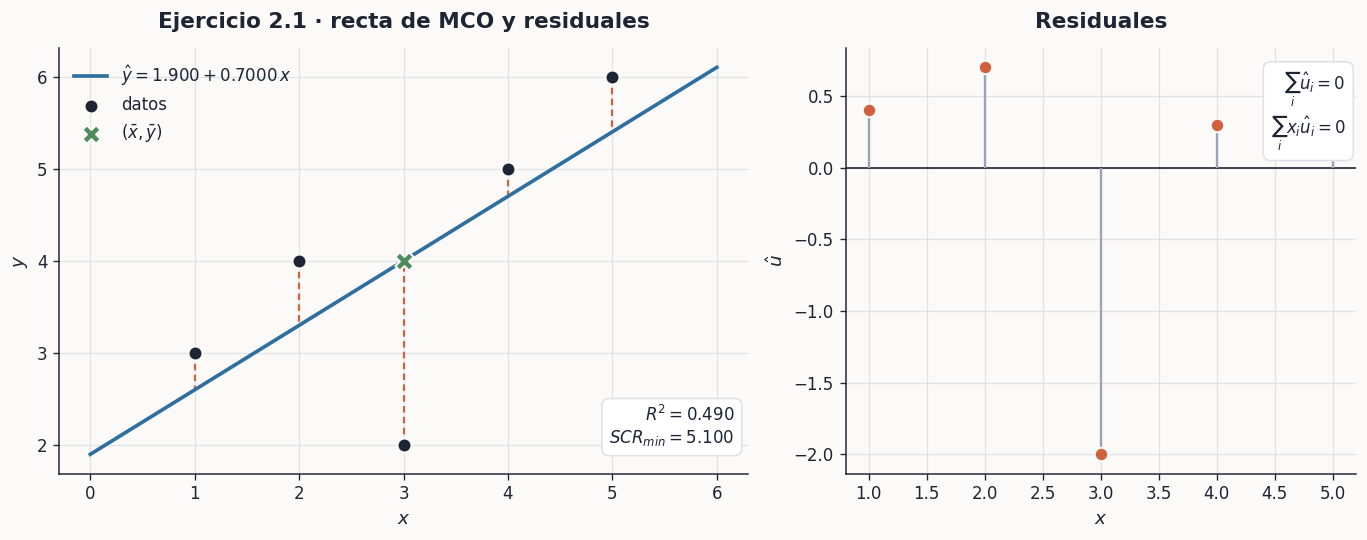

In [ ]:
print("EJERCICIO 3: MCO a partir de datos")

TINTA, AZUL, NARANJA, VERDE, GRIS, FONDO = "#1d2433", "#2f6f9f", "#d1603d", "#4c8b5b", "#9aa3b2", "#fbfaf8"

mpl.rcParams.update({
    "figure.facecolor": FONDO, "axes.facecolor": FONDO, "savefig.facecolor": FONDO,
    "axes.edgecolor": TINTA, "axes.linewidth": 0.9, "axes.labelcolor": TINTA,
    "axes.titlesize": 13, "axes.titleweight": "semibold", "axes.titlepad": 12,
    "axes.labelsize": 11, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": TINTA, "ytick.color": TINTA, "text.color": TINTA,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "font.family": "DejaVu Sans", "figure.dpi": 120, "savefig.dpi": 220,
    "grid.color": "#dfe3e8", "grid.linewidth": 0.8, "axes.grid": True,
    "axes.axisbelow": True, "legend.frameon": False, "legend.fontsize": 10,
})


def mco(x, y):
    """Estimadores de MCO en la regresion lineal simple, con las formulas de la hoja."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    xb, yb = x.mean(), y.mean() #Defines que xb, yb son xpromedio. ypromedio
    dx, dy = x - xb, y - yb

    Sxx, Syy, Sxy = dx @ dx, dy @ dy, dx @ dy

    b1 = Sxy / Sxx                 # beta_1 = Sxy / Sxx
    b0 = yb - b1 * xb              # beta_0 = ybar - beta_1 * xbar
    SSE = Sxy**2 / Sxx             # Suma de los cuadrados de los errores
    SSR = Syy - SSE
    SST = Syy

    yhat = b0 + b1 * x
    u = y - yhat

    SSR = u @ u #SSR=Syy
    SSE = Syy - SSR #Debe de dar 0
    return dict(x=x, y=y, n=x.size, xb=xb, yb=yb, Sxx=Sxx, Syy=Syy, Sxy=Sxy,
                b0=b0, b1=b1, yhat=yhat, u=u, SST=Syy, SSE=SSE, SSR=SSR,
                R2=SSE / Syy, rho=Sxy / np.sqrt(Sxx * Syy))


def resumen(r, titulo=""):
    if titulo:
        print(titulo)
        print("=" * len(titulo))
    print(f"n = {r['n']:d}      x̄ = {r['xb']:.6g}      ȳ = {r['yb']:.6g}")
    print(f"Sxx = {r['Sxx']:.6g}    Syy = {r['Syy']:.6g}    Sxy = {r['Sxy']:.6g}")
    print(f"β̂1 = {r['b1']:.6f}     β̂0 = {r['b0']:.6f}")
    print(f"SCRmin = {r['SSR']:.6f}   SSE = {r['SSE']:.6f}   SST = {r['SST']:.6f}")
    print(f"R² = {r['R2']:.6f}    ρ̂xy = {r['rho']:.6f}")
    print(f"[ecuaciones normales]  Σûᵢ = {r['u'].sum():.2e}    Σxᵢûᵢ = {r['x'] @ r['u']:.2e}")
    print(f"Funcion = {r['b0']:.6f} +{r['b1']:.6f} x")
    print(f"SSE = {r['SSE']:.6f}    SSR = {r['SSR']:.6f}    SST = {r['SST']:.6f}")
    print(f"SST = {r['SSE']:.6f} + {r['SSR']:.6f}= {r['SST']:.6f} (comprobación SSE+SSR)")


x1 = np.array([1, 2, 3, 4, 5], float)
y1 = np.array([3, 4, 2, 5, 6], float)
r1 = mco(x1, y1)

print(f"{'i':>2} {'xᵢ':>5} {'yᵢ':>5} {'xᵢ-x̄':>7} {'yᵢ-ȳ':>7} {'producto':>9} {'(xᵢ-x̄)²':>9}")
for i, (xi, yi) in enumerate(zip(x1, y1), start=1):
    dx, dy = xi - r1["xb"], yi - r1["yb"]
    print(f"{i:>2} {xi:>5.0f} {yi:>5.0f} {dx:>7.1f} {dy:>7.1f} {dx*dy:>9.2f} {dx**2:>9.2f}")
print(f"{'Σ':>2} {'':>5} {'':>5} {'':>7} {'':>7} {r1['Sxy']:>9.2f} {r1['Sxx']:>9.2f}")
print()

resumen(r1)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.6), gridspec_kw={"width_ratios": [1.35, 1]})

gx = np.linspace(x1.min() - 1, x1.max() + 1, 200)
ax1.plot(gx, r1["b0"] + r1["b1"] * gx, color=AZUL, lw=2.2, zorder=2,
         label=f"$\\hat{{y}} = {r1['b0']:.3f} + {r1['b1']:.4f}\\,x$")
for xi, yi, yh in zip(x1, y1, r1["yhat"]):
    ax1.plot([xi, xi], [yi, yh], color=NARANJA, lw=1.3, ls=(0, (3, 2)), zorder=1)
ax1.scatter(x1, y1, s=70, color=TINTA, zorder=3, ec=FONDO, lw=1.2, label="datos")
ax1.scatter([r1["xb"]], [r1["yb"]], s=120, marker="X", color=VERDE, zorder=4, ec=FONDO, lw=1.2,
            label=r"$(\bar{x},\bar{y})$")
ax1.set(xlabel="$x$", ylabel="$y$", title="Ejercicio 2.1 · recta de MCO y residuales")
ax1.legend(loc="upper left")
ax1.text(0.98, 0.06, f"$R^2 = {r1['R2']:.3f}$\n$SCR_{{min}} = {r1['SSR']:.3f}$",
         transform=ax1.transAxes, ha="right", va="bottom", fontsize=10,
         bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="#dfe3e8"))

ax2.axhline(0, color=TINTA, lw=1)
ax2.vlines(x1, 0, r1["u"], color=GRIS, lw=1.4)
ax2.scatter(x1, r1["u"], s=65, color=NARANJA, zorder=3, ec=FONDO, lw=1.2)
ax2.set(xlabel="$x$", ylabel=r"$\hat{u}$", title="Residuales")
ax2.text(0.98, 0.95, r"$\sum_i \hat{u}_i = 0$" + "\n" + r"$\sum_i x_i\hat{u}_i = 0$",
         transform=ax2.transAxes, ha="right", va="top", fontsize=10,
         bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="#dfe3e8"))

fig.tight_layout()
plt.show()

In [ ]:
print("EJERCICIO 5: Aproximacion normal a partir de variables de bernoulli")

# Parámetros del problema
n = 225
p = 0.2
q = 1 - p

# a) Bernoulli(p) a partir de la definición
e_xi = 1 * p + 0 * q
var_xi = (1**2 * p + 0**2 * q) - (e_xi**2)

print("a) Parámetros de Xi ~ Bernoulli(p):")
print(f"   E[Xi]   = {e_xi:.4f}")
print(f"   Var(Xi) = {var_xi:.4f}")

# b) Suma de n variables Y = Sum(Xi)
e_y = n * e_xi
var_y = n * var_xi
sigma_y = np.sqrt(var_y)

print("\nb) Parámetros de Y:")
print(f"   E[Y]    = {e_y:.1f}")
print(f"   Var(Y)  = {var_y:.1f}")
print(f"   Raíz(Var(Y)) = {sigma_y:.1f}")

# c) Estandarización y aproximación normal P(39 < Y < 51)
y1, y2 = 39, 51
z1 = (y1 - e_y) / sigma_y
z2 = (y2 - e_y) / sigma_y

# Dato de la tabla: Z(1) = Phi(1) = 0.8413
phi_1 = 0.8413
# Por simetría: Phi(-1) = 1 - Phi(1)
phi_neg_1 = 1 - phi_1
prob_aprox = phi_1 - phi_neg_1  # 2 * Phi(1) - 1

print("\nc) Teorema del Límite Central:")
print(f"   z1 = ({y1} - {e_y:.0f}) / {sigma_y:.0f} = {z1:.2f}")
print(f"   z2 = ({y2} - {e_y:.0f}) / {sigma_y:.0f} = {z2:.2f}")
print(f"   P(39 < Y < 51) ≈ P({z1:.0f} < Z < {z2:.0f})")
print(f"   = Phi(1) - Phi(-1) = {phi_1} - {phi_neg_1:.4f} = {prob_aprox:.4f}")

EJERCICIO 5: Aproximacion normal a partir de variables de bernoulli
a) Parámetros de Xi ~ Bernoulli(p):
   E[Xi]   = 0.2000
   Var(Xi) = 0.1600

b) Parámetros de Y:
   E[Y]    = 45.0
   Var(Y)  = 36.0
   Raíz(Var(Y)) = 6.0

c) Teorema del Límite Central:
   z1 = (39 - 45) / 6 = -1.00
   z2 = (51 - 45) / 6 = 1.00
   P(39 < Y < 51) ≈ P(-1 < Z < 1)
   = Phi(1) - Phi(-1) = 0.8413 - 0.1587 = 0.6826
